In [1]:
import os
import cv2
import matplotlib.pyplot as plt

In [7]:
# =====================================================
# RUTAS
# =====================================================

RUTAS = {
    "LR x2"    : "dataset/Training_LR_escala2/s1",
    "CLAHE x2" : "dataset/CLAHE/Training_CLAHE_escala2/s1",
    "SRCNN x2" : "dataset/Super_resolution/Training_SR_escala2/s1",

    "LR x4"    : "dataset/Training_LR_escala4/s1",
    "CLAHE x4" : "dataset/CLAHE/Training_CLAHE_escala4/s1",
    "SRCNN x4" : "dataset/Super_resolution/Training_SR_escala4/s1"
}
ETIQUETAS = [
    "LR (Escala ×2)",
    "CLAHE (Escala ×2)",
    "SRCNN (Escala ×2)",

    "LR (Escala ×4)",
    "CLAHE (Escala ×4)",
    "SRCNN (Escala ×4)"
]


In [8]:
archivos = sorted([
    f for f in os.listdir(RUTAS["LR x2"])
    if f.lower().endswith(".png")
])

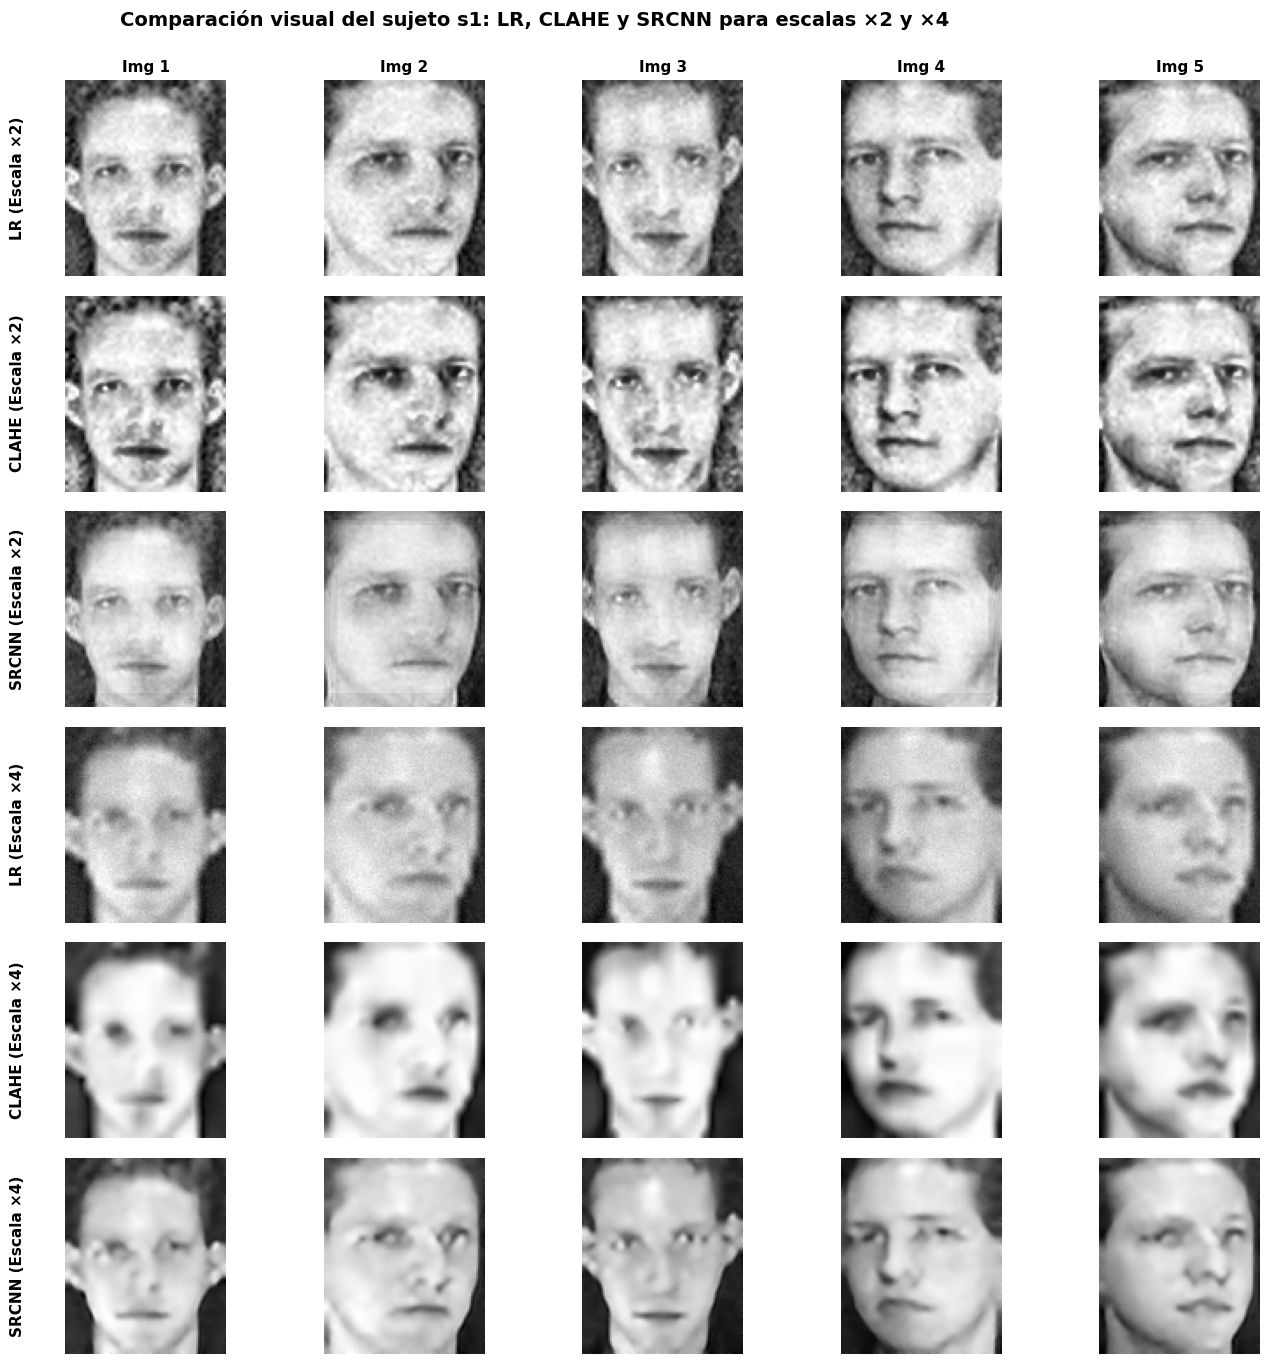

In [11]:
fig, axes = plt.subplots(
    nrows=6,
    ncols=num_imgs,
    figsize=(16, 14)
)

# Ajustar márgenes para dar espacio a las etiquetas de fila
plt.subplots_adjust(left=0.18, top=0.93, bottom=0.02, right=0.98, hspace=0.1, wspace=0.05)

for fila, ((nombre, ruta_base), etiqueta) in enumerate(
        zip(RUTAS.items(), ETIQUETAS)):
    for col in range(num_imgs):
        archivo = archivos[col]
        ruta_img = os.path.join(ruta_base, archivo)
        img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

        ax = axes[fila, col]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        # Título de columna (solo fila 0)
        if fila == 0:
            ax.set_title(
                f"Img {col+1}",
                fontsize=11,
                fontweight='bold'
            )

        #  Etiqueta de fila en la primera columna usando text()
        if col == 0:
            ax.text(
                x=-0.25,           # posición a la izquierda del subplot
                y=0.5,             # centrado verticalmente
                s=etiqueta,
                fontsize=11,
                fontweight='bold',
                ha='right',
                va='center',
                rotation=90,
                transform=ax.transAxes  # coordenadas relativas al eje
            )
plt.suptitle(
    "Comparación visual del sujeto s1: LR, CLAHE y SRCNN para escalas ×2 y ×4",
    fontsize=14,
    fontweight='bold'
)

plt.savefig("comparacion_s1.png", dpi=150, bbox_inches='tight')
plt.show()